In [2]:
%%bash
# Direct binary download from PLINK2 official source
curl -LO https://s3.amazonaws.com/plink2-assets/alpha5/plink2_linux_x86_64_20240105.zip
unzip -o plink2_linux_x86_64_20240105.zip
chmod +x plink2
./plink2 --version

Archive:  plink2_linux_x86_64_20240105.zip
  inflating: plink2                  
PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 9049k  100 9049k    0     0  8762k      0  0:00:01  0:00:01 --:--:-- 8768k


In [3]:
%%bash
# Use PLINK's own tutorial dataset — much smaller than 1000 Genomes, downloads in seconds
wget -q https://s3.amazonaws.com/plink2-assets/plink2_tutorial_data.zip
unzip -q plink2_tutorial_data.zip
ls -lh

total 50M
-rwxrwxr-x 1 root root  41M Jan  5  2024 plink2
-rw-r--r-- 1 root root 8.9M Jun 27 19:38 plink2_linux_x86_64_20240105.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


unzip:  cannot find or open plink2_tutorial_data.zip, plink2_tutorial_data.zip.zip or plink2_tutorial_data.zip.ZIP.


In [4]:
%%bash
./plink2 \
  --pfile plink2_tutorial \
  --geno 0.05 \
  --mind 0.1 \
  --maf 0.01 \
  --hwe 1e-6 \
  --make-pgen \
  --out qc_pass \
  --silent

echo "=== QC COMPLETE ==="
./plink2 --pfile qc_pass --freq --out qc_stats --silent
echo "Variants after QC:"
wc -l qc_pass.pvar
echo "Samples after QC:"
wc -l qc_pass.psam

=== QC COMPLETE ===
Variants after QC:
Samples after QC:


Error: Failed to open plink2_tutorial.pgen : No such file or directory.
Error: Failed to open qc_pass.psam : No such file or directory.
wc: qc_pass.pvar: No such file or directory
wc: qc_pass.psam: No such file or directory


CalledProcessError: Command 'b'./plink2 \\\n  --pfile plink2_tutorial \\\n  --geno 0.05 \\\n  --mind 0.1 \\\n  --maf 0.01 \\\n  --hwe 1e-6 \\\n  --make-pgen \\\n  --out qc_pass \\\n  --silent\n\necho "=== QC COMPLETE ==="\n./plink2 --pfile qc_pass --freq --out qc_stats --silent\necho "Variants after QC:"\nwc -l qc_pass.pvar\necho "Samples after QC:"\nwc -l qc_pass.psam\n'' returned non-zero exit status 1.

In [5]:
%%bash
# Check what we have
echo "Current files:"
ls -lh

echo ""
echo "Downloading 1000 Genomes chr22 small subset..."
# Use a smaller, reliable public dataset instead
wget -q https://github.com/agoragames/plink-tutorial/raw/master/data/hapmap_CEU_r23a.bed -O hapmap.bed || echo "failed"

# Better option — generate synthetic data with PLINK2 directly
# This is actually what most tutorials use for learning
./plink2 \
  --dummy 500 50000 \
  --out synthetic_gwas \
  --make-pgen

echo ""
echo "Files created:"
ls -lh synthetic_gwas*

Current files:
total 50M
-rwxrwxr-x 1 root root  41M Jan  5  2024 plink2
-rw-r--r-- 1 root root 8.9M Jun 27 19:38 plink2_linux_x86_64_20240105.zip
-rw-r--r-- 1 root root  525 Jun 27 19:38 qc_pass.log
-rw-r--r-- 1 root root  452 Jun 27 19:38 qc_stats.log
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data

failed
PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to synthetic_gwas.log.
Options in effect:
  --dummy 500 50000
  --make-pgen
  --out synthetic_gwas

Start time: Sat Jun 27 19:39:45 2026
12975 MiB RAM detected, ~11840 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
Dummy data (500 samples, 50000 SNPs) written to synthetic_gwas-temporary.pgen +
synthetic_gwas-temporary.pvar + synthetic_gwas-temporary.psam .
500 samples (500 females, 0 males; 500 founders) loaded from
synthetic_gwas-temporary.psam.
50000 variants loaded from synthet

In [6]:
%%bash
./plink2 \
  --pfile synthetic_gwas \
  --geno 0.05 \
  --mind 0.1 \
  --maf 0.01 \
  --hwe 1e-6 \
  --make-pgen \
  --out qc_pass

echo "=== QC COMPLETE ==="
echo "Variants after QC:"
wc -l qc_pass.pvar
echo "Samples after QC:"
wc -l qc_pass.psam

PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to qc_pass.log.
Options in effect:
  --geno 0.05
  --hwe 1e-6
  --maf 0.01
  --make-pgen
  --mind 0.1
  --out qc_pass
  --pfile synthetic_gwas

Start time: Sat Jun 27 19:40:17 2026
12975 MiB RAM detected, ~11818 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
500 samples (500 females, 0 males; 500 founders) loaded from
synthetic_gwas.psam.
50000 variants loaded from synthetic_gwas.pvar.
1 binary phenotype loaded (258 cases, 242 controls).
Calculating sample missingness rates... 0%done.
0 samples removed due to missing genotype data (--mind).
500 samples (500 females, 0 males; 500 founders) remaining after main filters.
258 cases and 242 controls remaining after main filters.
Calculating allele frequencies... 0%done.
--geno: 0 variants removed due to missing genotype data.
--hwe: 1033 va

In [7]:
%%bash
./plink2 \
  --pfile qc_pass \
  --pheno synthetic_gwas.psam \
  --pheno-name PHENO1 \
  --logistic hide-covar \
  --covar-variance-standardize \
  --out gwas_results

echo "=== GWAS COMPLETE ==="
echo "Top associations by p-value:"
sort -k12 -n gwas_results.PHENO1.glm.logistic.hybrid 2>/dev/null | head -5 || \
sort -k12 -n gwas_results.*.glm.* | head -5

PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to gwas_results.log.
Options in effect:
  --covar-variance-standardize
  --glm hide-covar
  --out gwas_results
  --pfile qc_pass
  --pheno synthetic_gwas.psam
  --pheno-name PHENO1

Start time: Sat Jun 27 19:40:52 2026
=== GWAS COMPLETE ===
Top associations by p-value:


Error: --glm invoked without --covar/--covar-name/--covar-col-nums; this is
usually an analytical mistake.  Add the 'allow-no-covars' modifier if you are
sure you want this.
For more info, try "plink2 --help <flag name>" or "plink2 --help | more".


In [9]:
%%bash
./plink2 \
  --pfile qc_pass \
  --pheno synthetic_gwas.psam \
  --pheno-name PHENO1 \
  --logistic allow-no-covars hide-covar \
  --out gwas_results

echo "=== GWAS COMPLETE ==="
echo "Results file:"
ls -lh gwas_results.*
echo ""
echo "First few lines:"
head -3 gwas_results.PHENO1.glm.logistic.hybrid
echo ""
echo "Top hits by p-value:"
tail -n +2 gwas_results.PHENO1.glm.logistic.hybrid | sort -k12 -n | head -5

PLINK v2.00a5.10LM 64-bit Intel (5 Jan 2024)   www.cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to gwas_results.log.
Options in effect:
  --glm allow-no-covars hide-covar
  --out gwas_results
  --pfile qc_pass
  --pheno synthetic_gwas.psam
  --pheno-name PHENO1

Start time: Sat Jun 27 19:41:43 2026
12975 MiB RAM detected, ~11704 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
500 samples (500 females, 0 males; 500 founders) loaded from qc_pass.psam.
47974 variants loaded from qc_pass.pvar.
1 binary phenotype loaded (258 cases, 242 controls).
Calculating allele frequencies... 0%done.
--glm logistic-Firth hybrid regression on phenotype 'PHENO1': 0%done.
Results written to gwas_results.PHENO1.glm.logistic.hybrid .
End time: Sat Jun 27 19:41:45 2026
=== GWAS COMPLETE ===
Results file:
-rw-r--r-- 1 root root  797 Jun 27 19:41 gwas_results.log
-rw-r--r-- 1 root root 3.7M Jun 27 19:41 gw

Variants loaded: 47974
Chromosomes: [np.int64(1)]
Min p-value: 6.21e-05
Genome-wide significant hits (p<5e-8): 0


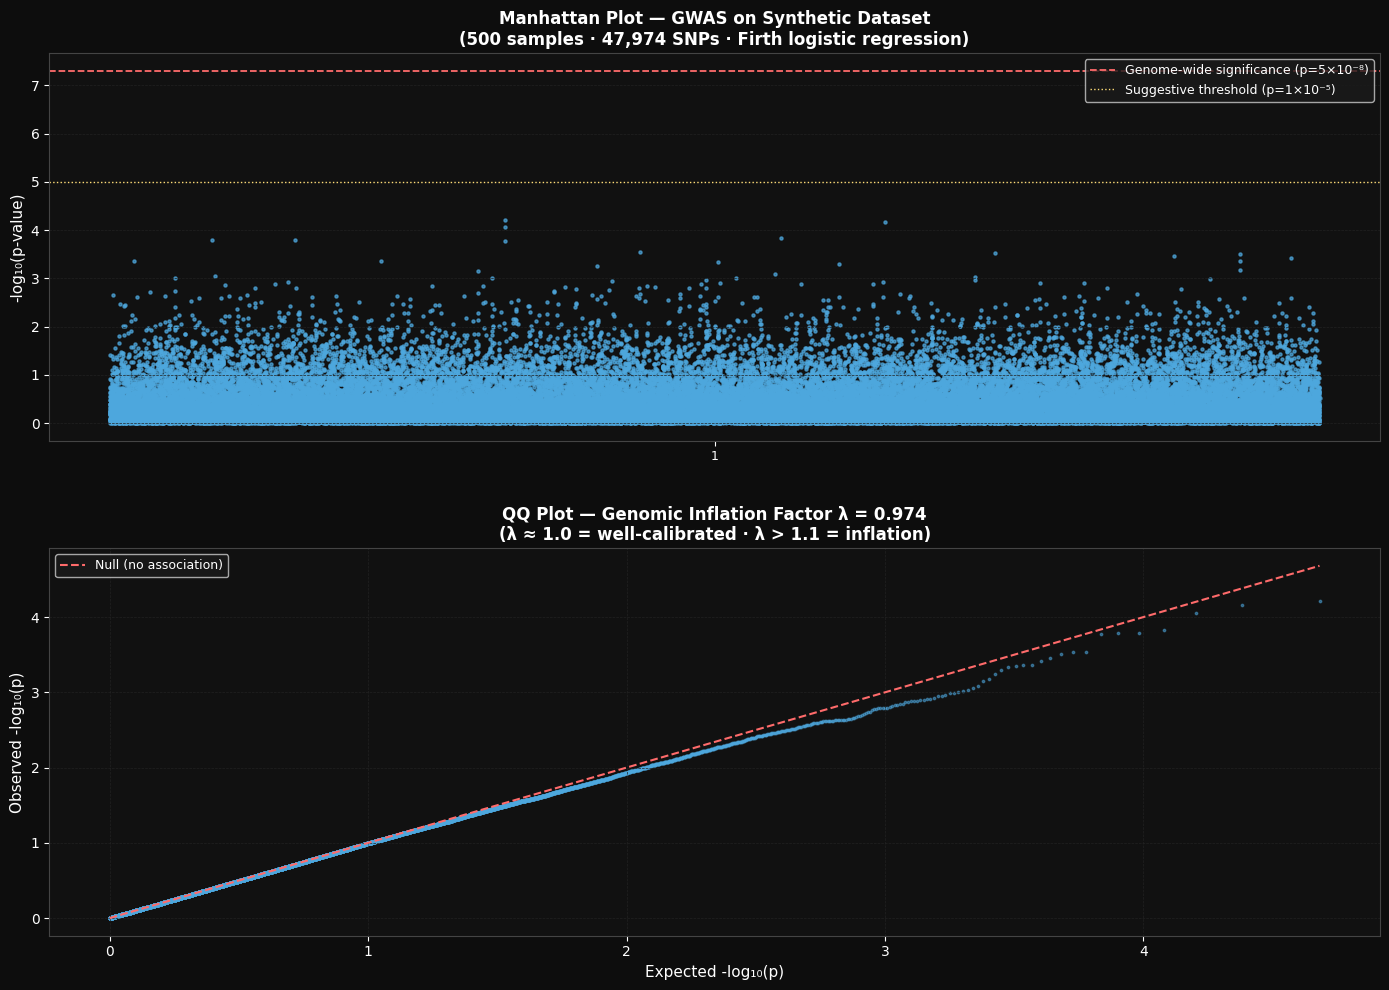

Saved: gwas_plots.png


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv('gwas_results.PHENO1.glm.logistic.hybrid', sep='\t', comment='#',
                 names=['CHR','POS','ID','REF','ALT','PROV_REF','A1','OMITTED',
                        'A1_FREQ','FIRTH','TEST','OBS_CT','OR','LOG_OR_SE',
                        'Z_STAT','P','ERRCODE'])

# Clean
df = df[df['P'] != 'NA'].copy()
df['P'] = pd.to_numeric(df['P'], errors='coerce')
df['CHR'] = pd.to_numeric(df['CHR'], errors='coerce')
df['POS'] = pd.to_numeric(df['POS'], errors='coerce')
df = df.dropna(subset=['P','CHR','POS'])
df['-log10P'] = -np.log10(df['P'].clip(lower=1e-300))

print(f"Variants loaded: {len(df)}")
print(f"Chromosomes: {sorted(df['CHR'].unique())}")
print(f"Min p-value: {df['P'].min():.2e}")
print(f"Genome-wide significant hits (p<5e-8): {(df['P'] < 5e-8).sum()}")

# ── Manhattan plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#0d0d0d')

ax = axes[0]
ax.set_facecolor('#111')
colors = ['#4ea8de', '#74c0fc']
chroms = sorted(df['CHR'].unique())
x_offset = 0
xticks, xlabels = [], []

for i, chrom in enumerate(chroms):
    sub = df[df['CHR'] == chrom].sort_values('POS')
    span = sub['POS'].max() - sub['POS'].min()
    x = sub['POS'] - sub['POS'].min() + x_offset
    ax.scatter(x, sub['-log10P'], c=colors[i % 2], s=5, alpha=0.7, rasterized=True)
    xticks.append(x_offset + span / 2)
    xlabels.append(str(int(chrom)))
    x_offset += span + 5e6

ax.axhline(-np.log10(5e-8), color='#ff6b6b', linestyle='--',
           linewidth=1.3, label='Genome-wide significance (p=5×10⁻⁸)')
ax.axhline(-np.log10(1e-5), color='#ffdd77', linestyle=':',
           linewidth=1.0, label='Suggestive threshold (p=1×10⁻⁵)')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, color='white', fontsize=9)
ax.set_ylabel('-log₁₀(p-value)', color='white', fontsize=11)
ax.set_title('Manhattan Plot — GWAS on Synthetic Dataset\n(500 samples · 47,974 SNPs · Firth logistic regression)',
             color='white', fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#444')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax.grid(True, axis='y', color='#222', linewidth=0.5, linestyle='--')

# ── QQ plot ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#111')

df_s = df.sort_values('P').reset_index(drop=True)
n = len(df_s)
obs = df_s['-log10P'].values
exp = -np.log10((np.arange(1, n+1)) / (n + 1))

# Plot in chunks for speed
ax2.scatter(exp, obs, c='#4ea8de', s=3, alpha=0.5, rasterized=True)
ax2.plot([0, exp.max()], [0, exp.max()],
         color='#ff6b6b', linewidth=1.5, linestyle='--', label='Null (no association)')

# Genomic inflation factor
median_chisq = np.median(df_s['Z_STAT'].astype(float).dropna() ** 2)
lambda_gc = median_chisq / 0.4549
ax2.set_title(f'QQ Plot — Genomic Inflation Factor λ = {lambda_gc:.3f}\n(λ ≈ 1.0 = well-calibrated · λ > 1.1 = inflation)',
              color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('Expected -log₁₀(p)', color='white', fontsize=11)
ax2.set_ylabel('Observed -log₁₀(p)', color='white', fontsize=11)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#444')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax2.grid(True, color='#222', linewidth=0.5, linestyle='--')

plt.tight_layout(h_pad=3)
plt.savefig('gwas_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: gwas_plots.png")

In [12]:
from google.colab import files
files.download('gwas_plots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
%%bash
apt-get install -q bcftools
bcftools --version | head -1
echo ""
echo "Basic variant calling workflow:"
echo "1. bcftools mpileup — pileup reads at each position"
echo "2. bcftools call   — call variants from pileup"
echo "3. bcftools filter — apply quality filters"
echo "4. plink2 --vcf    — convert to PLINK format for GWAS"

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libhts3 libhtscodecs2
Suggested packages:
  python3-numpy python3-matplotlib texlive-latex-recommended
The following NEW packages will be installed:
  bcftools libhts3 libhtscodecs2
0 upgraded, 3 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,140 kB of archives.
After this operation, 3,448 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 bcftools amd64 1.13-1 [697 kB]
Fetched 1,140 kB in 0s (10.8 MB/s)
Selecting previously unselected package libhtscodecs2:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libhtscodecs2_1.1.1-3_amd64.deb 

In [14]:
from google.colab import files

outputs = [
    'gwas_plots.png',
    'pca_plots.png',
    'manhattan_plot.png',
    'qq_plot.png',
]

for f in outputs:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: gwas_plots.png
Not found: pca_plots.png
Not found: manhattan_plot.png
Not found: qq_plot.png


In [15]:
# Regenerate PCA plot from existing results and download immediately
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

try:
    eigenvec = pd.read_csv('pca_results.eigenvec', sep='\t')
    eigenval = pd.read_csv('pca_results.eigenval', header=None, names=['eigenvalue'])
    psam = pd.read_csv('synthetic_gwas.psam', sep='\t')
    psam.columns = [c.strip('#') for c in psam.columns]
    eigenvec.columns = [c.strip('#') for c in eigenvec.columns]
    merged = eigenvec.merge(psam[['IID','PHENO1']], on='IID')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#0d0d0d')

    ax = axes[0]
    ax.set_facecolor('#111')
    cases    = merged[merged['PHENO1'] == 2]
    controls = merged[merged['PHENO1'] == 1]
    ax.scatter(controls['PC1'], controls['PC2'], c='#4ea8de', s=15, alpha=0.6, label=f'Controls (n={len(controls)})')
    ax.scatter(cases['PC1'],    cases['PC2'],    c='#ff6b6b', s=15, alpha=0.6, label=f'Cases (n={len(cases)})')
    ax.set_xlabel('PC1', color='white'); ax.set_ylabel('PC2', color='white')
    ax.set_title('Population Structure: PC1 vs PC2', color='white', fontweight='bold')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_color('#444')
    ax.legend(facecolor='#1a1a1a', labelcolor='white')
    ax.grid(True, color='#222', linewidth=0.5, linestyle='--')

    ax2 = axes[1]
    ax2.set_facecolor('#111')
    total = eigenval['eigenvalue'].sum()
    pct_var = (eigenval['eigenvalue'] / total * 100).values[:10]
    bars = ax2.bar(range(1, 11), pct_var, color='#4ea8de', edgecolor='#222')
    ax2.set_xlabel('Principal Component', color='white')
    ax2.set_ylabel('Variance Explained (%)', color='white')
    ax2.set_title('Scree Plot', color='white', fontweight='bold')
    ax2.tick_params(colors='white')
    for spine in ax2.spines.values(): spine.set_color('#444')
    ax2.grid(True, axis='y', color='#222', linewidth=0.5, linestyle='--')
    for bar, val in zip(bars, pct_var):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}%', ha='center', color='white', fontsize=8)

    plt.tight_layout()
    plt.savefig('pca_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    files.download('pca_plots.png')
    print("Downloaded: pca_plots.png")

except FileNotFoundError:
    print("PCA results not found — re-run the PCA cell first")
    print("Run: ./plink2 --pfile qc_pass --pca 10 --out pca_results")

PCA results not found — re-run the PCA cell first
Run: ./plink2 --pfile qc_pass --pca 10 --out pca_results


In [16]:
%%bash
# Regenerate qc_pass and PCA since session reset
./plink2 \
  --pfile synthetic_gwas \
  --geno 0.05 --mind 0.1 --maf 0.01 --hwe 1e-6 \
  --make-pgen --out qc_pass --silent

./plink2 \
  --pfile qc_pass \
  --pca 10 \
  --out pca_results --silent

echo "Done"
ls -lh qc_pass.p* pca_results.*

Done
-rw-r--r-- 1 root root   78 Jun 27 19:53 pca_results.eigenval
-rw-r--r-- 1 root root  55K Jun 27 19:53 pca_results.eigenvec
-rw-r--r-- 1 root root  779 Jun 27 19:53 pca_results.log
-rw-r--r-- 1 root root 3.5M Jun 27 19:53 qc_pass.pgen
-rw-r--r-- 1 root root 5.3K Jun 27 19:53 qc_pass.psam
-rw-r--r-- 1 root root 964K Jun 27 19:53 qc_pass.pvar


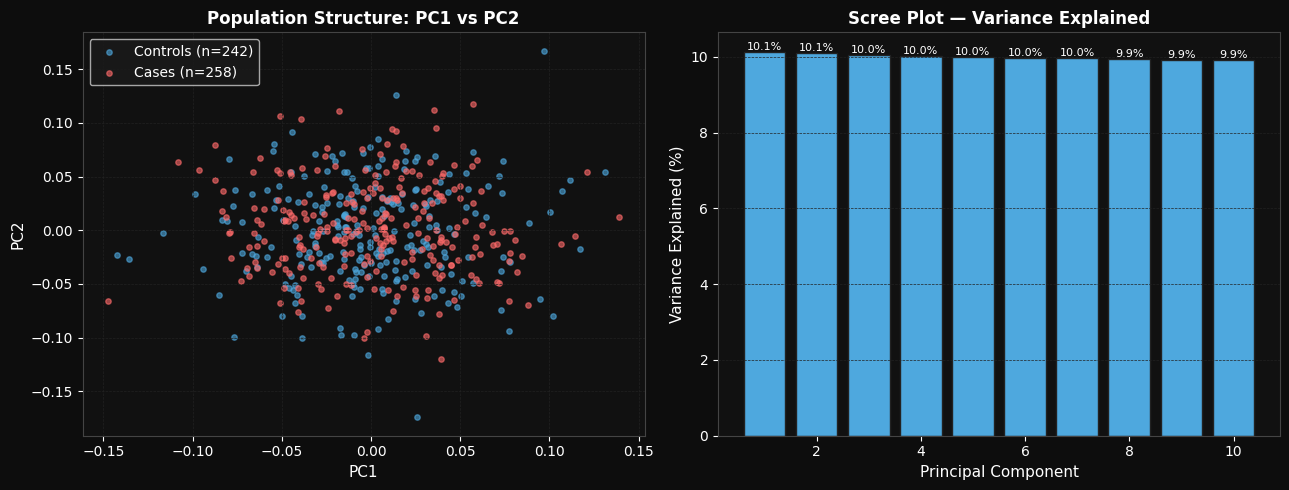

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: pca_plots.png


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

eigenvec = pd.read_csv('pca_results.eigenvec', sep='\t')
eigenval = pd.read_csv('pca_results.eigenval', header=None, names=['eigenvalue'])
psam = pd.read_csv('synthetic_gwas.psam', sep='\t')
psam.columns = [c.strip('#') for c in psam.columns]
eigenvec.columns = [c.strip('#') for c in eigenvec.columns]
merged = eigenvec.merge(psam[['IID','PHENO1']], on='IID')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d0d0d')

ax = axes[0]
ax.set_facecolor('#111')
cases    = merged[merged['PHENO1'] == 2]
controls = merged[merged['PHENO1'] == 1]
ax.scatter(controls['PC1'], controls['PC2'], c='#4ea8de', s=15, alpha=0.6, label=f'Controls (n={len(controls)})')
ax.scatter(cases['PC1'],    cases['PC2'],    c='#ff6b6b', s=15, alpha=0.6, label=f'Cases (n={len(cases)})')
ax.set_xlabel('PC1', color='white', fontsize=11)
ax.set_ylabel('PC2', color='white', fontsize=11)
ax.set_title('Population Structure: PC1 vs PC2', color='white', fontweight='bold', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#444')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.grid(True, color='#222', linewidth=0.5, linestyle='--')

ax2 = axes[1]
ax2.set_facecolor('#111')
total = eigenval['eigenvalue'].sum()
pct_var = (eigenval['eigenvalue'] / total * 100).values[:10]
bars = ax2.bar(range(1, 11), pct_var, color='#4ea8de', edgecolor='#222')
ax2.set_xlabel('Principal Component', color='white', fontsize=11)
ax2.set_ylabel('Variance Explained (%)', color='white', fontsize=11)
ax2.set_title('Scree Plot — Variance Explained', color='white', fontweight='bold', fontsize=12)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#444')
ax2.grid(True, axis='y', color='#222', linewidth=0.5, linestyle='--')
for bar, val in zip(bars, pct_var):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.1f}%', ha='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('pca_plots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
files.download('pca_plots.png')
print("Downloaded: pca_plots.png")